In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

print("NumPy version:", np.__version__)
print("Neural Network From Scratch")

NumPy version: 2.0.2
Neural Network From Scratch


In [2]:
# XOR input data
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

# Expected outputs
y = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=float)

print("Input:")
print(X)

print("\nExpected Output:")
print(y)

Input:
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

Expected Output:
[[0.]
 [1.]
 [1.]
 [0.]]


In [3]:
def relu(x):
    return np.maximum(0, x)


def relu_derivative(x):
    return (x > 0).astype(float)


def sigmoid(x):
    # Prevent overflow
    x = np.clip(x, -500, 500)
    return 1 / (1 + np.exp(-x))


def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

In [4]:
def binary_cross_entropy(y_true, y_pred):
    epsilon = 1e-8

    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    loss = -(
        y_true * np.log(y_pred) +
        (1 - y_true) * np.log(1 - y_pred)
    )

    return np.mean(loss)

In [5]:
input_size = 2
hidden_size = 4
output_size = 1

# Initialize weights
W1 = np.random.randn(input_size, hidden_size) * 0.5
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * 0.5
b2 = np.zeros((1, output_size))

print("W1 shape:", W1.shape)
print("b1 shape:", b1.shape)

print("W2 shape:", W2.shape)
print("b2 shape:", b2.shape)

W1 shape: (2, 4)
b1 shape: (1, 4)
W2 shape: (4, 1)
b2 shape: (1, 1)


In [6]:
def forward_propagation(X):

    # Hidden layer
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)

    # Output layer
    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)

    cache = {
        "Z1": Z1,
        "A1": A1,
        "Z2": Z2,
        "A2": A2
    }

    return A2, cache

In [7]:
predictions, cache = forward_propagation(X)

print("Predictions before training:")
print(predictions)

Predictions before training:
[[0.5       ]
 [0.43233932]
 [0.42295211]
 [0.36458997]]


In [8]:
def backward_propagation(X, y, cache):

    m = X.shape[0]

    Z1 = cache["Z1"]
    A1 = cache["A1"]
    A2 = cache["A2"]

    # Output layer gradients
    dZ2 = A2 - y

    dW2 = np.dot(A1.T, dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    # Hidden layer gradients
    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * relu_derivative(Z1)

    dW1 = np.dot(X.T, dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    gradients = {
        "dW1": dW1,
        "db1": db1,
        "dW2": dW2,
        "db2": db2
    }

    return gradients

In [9]:
def update_parameters(gradients, learning_rate):

    global W1, b1, W2, b2

    W1 -= learning_rate * gradients["dW1"]
    b1 -= learning_rate * gradients["db1"]

    W2 -= learning_rate * gradients["dW2"]
    b2 -= learning_rate * gradients["db2"]

In [10]:
epochs = 10000
learning_rate = 0.1

loss_history = []

for epoch in range(epochs):

    # Forward propagation
    predictions, cache = forward_propagation(X)

    # Calculate loss
    loss = binary_cross_entropy(y, predictions)

    # Backpropagation
    gradients = backward_propagation(X, y, cache)

    # Update weights
    update_parameters(gradients, learning_rate)

    loss_history.append(loss)

    if epoch % 1000 == 0:
        print(f"Epoch {epoch:5d} | Loss: {loss:.6f}")

Epoch     0 | Loss: 0.711418
Epoch  1000 | Loss: 0.480781
Epoch  2000 | Loss: 0.478543
Epoch  3000 | Loss: 0.478039
Epoch  4000 | Loss: 0.477831
Epoch  5000 | Loss: 0.477680
Epoch  6000 | Loss: 0.477647
Epoch  7000 | Loss: 0.477581
Epoch  8000 | Loss: 0.477552
Epoch  9000 | Loss: 0.477544


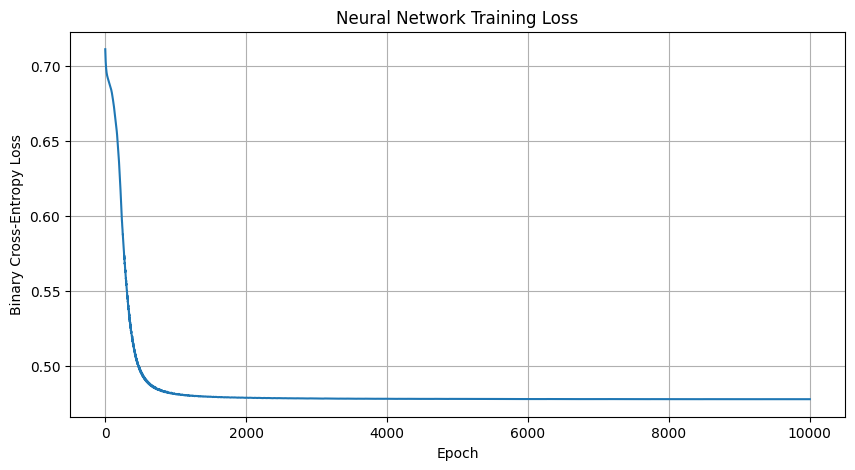

In [11]:
plt.figure(figsize=(10, 5))

plt.plot(loss_history)

plt.title("Neural Network Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")

plt.grid(True)
plt.show()

In [12]:
predictions, _ = forward_propagation(X)

print("Raw predictions:")
print(predictions)

Raw predictions:
[[6.66486640e-01]
 [6.66486640e-01]
 [6.66486640e-01]
 [5.40545227e-04]]


In [13]:
predicted_classes = (predictions >= 0.5).astype(int)

print("\nPredicted classes:")
print(predicted_classes)

print("\nActual classes:")
print(y.astype(int))


Predicted classes:
[[1]
 [1]
 [1]
 [0]]

Actual classes:
[[0]
 [1]
 [1]
 [0]]


In [14]:
accuracy = np.mean(predicted_classes == y) * 100

print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 75.00%


In [15]:
def predict(input_data):

    input_data = np.array(input_data, dtype=float)

    if input_data.ndim == 1:
        input_data = input_data.reshape(1, -1)

    probabilities, _ = forward_propagation(input_data)

    classes = (probabilities >= 0.5).astype(int)

    return probabilities, classes

In [16]:
tests = [
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
]

for test in tests:

    probability, prediction = predict(test)

    print(
        f"Input: {test} "
        f"| Probability: {probability[0][0]:.4f} "
        f"| Prediction: {prediction[0][0]}"
    )

Input: [0, 0] | Probability: 0.6665 | Prediction: 1
Input: [0, 1] | Probability: 0.6665 | Prediction: 1
Input: [1, 0] | Probability: 0.6665 | Prediction: 1
Input: [1, 1] | Probability: 0.0005 | Prediction: 0


In [17]:
input_value = [1, 0]

probability, prediction = predict(input_value)

print("Input:", input_value)
print("Probability:", probability[0][0])
print("Prediction:", prediction[0][0])

Input: [1, 0]
Probability: 0.6664866401914326
Prediction: 1


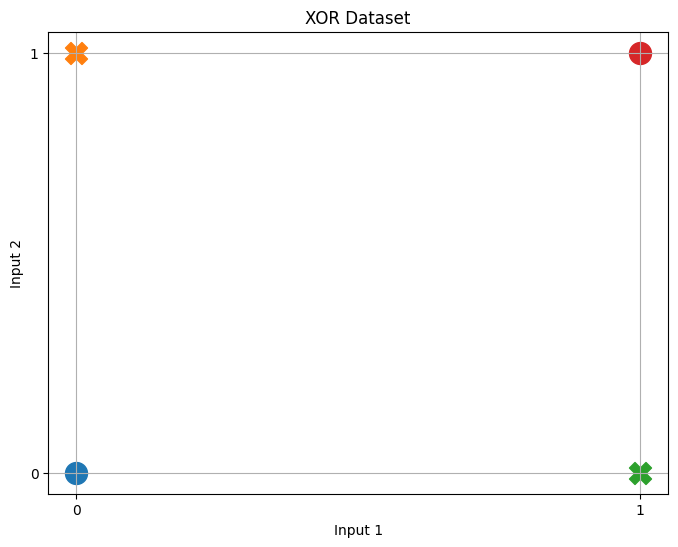

In [19]:
plt.figure(figsize=(8, 6))

for i in range(len(X)):

    if y[i][0] == 0:
        marker = "o"
    else:
        marker = "X"

    plt.scatter(
        X[i, 0],
        X[i, 1],
        s=250,
        marker=marker,
        label=f"Class {int(y[i][0])}" if i < 2 else ""
    )

plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.title("XOR Dataset")

plt.xticks([0, 1])
plt.yticks([0, 1])

plt.grid(True)
plt.show()